<a href="https://colab.research.google.com/github/apry0512/SENTIMENT-ANALYSIS-ASSIGNMENT-2/blob/main/NLP_Assignment2_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ITNPAI3 Assignment 2 - Sentiment Analysis

Student: Aparajita Singh

Student Number: 3539316

Subject Code: ITNPAI3

Assignment: 2

Using the same twitter dataset from assignment 1. This time building two neural models instead of the classical ML stuff.
Going with BiLSTM and DistilBERT - should be interesting to see how much better BERT actually does on something this small.

In [ ]:
# !pip install torch transformers scikit-learn pandas numpy matplotlib seaborn

import re
import csv
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup

# setting seeds everywhere so results are reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'running on: {DEVICE}')

running on: cuda


## Task 1 - Preprocessing

Had to rethink the preprocessing quite a bit compared to assignment 1. For TF-IDF it was fine to just strip everything and lowercase, but for neural models that actually loses useful information. The main things I changed:
- keeping emojis but converting them to tokens instead of just deleting them
- keeping negations and contractions intact (splitting dont into do not felt wrong)
- keeping punctuation like ! and ? since those actually carry sentiment

The BERT path is slightly different - no lowercasing since distilbert-base-uncased handles that internally, and the WordPiece tokeniser deals with OOV words by splitting them into subwords so we don't need the same vocab tricks as the BiLSTM.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving testdata.manual.2009.06.14.csv to testdata.manual.2009.06.14.csv


In [ ]:
import io
raw_bytes = list(uploaded.values())[0]

rows = []
reader = csv.reader(io.StringIO(raw_bytes.decode('utf-8', errors='replace')))
for row in reader:
    if len(row) >= 6:
        try:
            rows.append({'polarity': int(row[0]), 'text': row[5]})
        except ValueError:
            pass

df = pd.DataFrame(rows)
df['label'] = df['polarity'].map({0: 0, 2: 1, 4: 2})

print('class counts:')
print(df['label'].value_counts())
print(f'\ntotal examples: {len(df)}')

class counts:
label
2    198
0    178
1    140
Name: count, dtype: int64

total examples: 516


In [ ]:
# emoji mapping - originally I tried just deleting emojis but that killed a lot of sentiment signal
# converting to descriptive tokens works much better
EMOJI_MAP = {
    r'[:=8][\-o\*\']?[\)\]\}D]': ' EMOJI_HAPPY ',
    r'[:=8][\-o\*\']?[\(\[\{]':  ' EMOJI_SAD ',
    r'[:=][\-o\*\']?[Pp]':        ' EMOJI_PLAYFUL ',
    r'[:=][\-o\*\']?[\|]':        ' EMOJI_NEUTRAL ',
    r'<3':                         ' EMOJI_LOVE ',
    r'</3':                        ' EMOJI_HEARTBREAK ',
    r'[xX][dD]':                   ' EMOJI_LAUGH ',
}

def preprocess_text(text, for_bert=False):
    # convert emoticons to tokens before anything else so they don't get mangled
    for pattern, token in EMOJI_MAP.items():
        text = re.sub(pattern, token, text)

    # remove URLs - no sentiment value and adds noise
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # replace @mentions with a generic USER token
    # tried keeping them but the model just memorises usernames which doesn't generalise
    text = re.sub(r'@\w+', 'USER', text)

    # keep the hashtag word but lose the #
    text = re.sub(r'#(\w+)', r'\1', text)

    # collapse repeated characters - loooove becomes loove (keep some emphasis)
    text = re.sub(r'(.)\1{3,}', r'\1\1', text)

    # only lowercase for BiLSTM - BERT's tokeniser handles casing itself
    if not for_bert:
        text = text.lower()

    # keep !, ?, . and ' for contractions - strip everything else
    text = re.sub(r'[^\w\s\.\?\!\'\,]', ' ', text)

    text = ' '.join(text.split())
    return text

df['text_clean'] = df['text'].apply(lambda x: preprocess_text(x, for_bert=False))
df['text_bert']  = df['text'].apply(lambda x: preprocess_text(x, for_bert=True))

# check it looks right
for i in [0, 3, 9]:
    print(f'--- example {i} ---')
    print('original:', df['text'].iloc[i])
    print('bilstm:  ', df['text_clean'].iloc[i])
    print('bert:    ', df['text_bert'].iloc[i])
    print()

--- example 0 ---
original: @stellargirl I loooooooovvvvvveee my Kindle2. Not that the DX is cool, but the 2 is fantastic in its own right.
bilstm:   user i loovveee my kindle2. not that the dx is cool, but the 2 is fantastic in its own right.
bert:     USER I loovveee my Kindle2. Not that the DX is cool, but the 2 is fantastic in its own right.

--- example 3 ---
original: @kenburbary You'll love your Kindle2. I've had mine for a few months and never looked back. The new big one is huge! No need for remorse! :)
bilstm:   user you'll love your kindle2. i've had mine for a few months and never looked back. the new big one is huge! no need for remorse! emoji_happy
bert:     USER You'll love your Kindle2. I've had mine for a few months and never looked back. The new big one is huge! No need for remorse! EMOJI_HAPPY

--- example 9 ---
original: how can you not love Obama? he makes jokes about himself.
bilstm:   how can you not love obama? he makes jokes about himself.
bert:     how can you

In [ ]:
# 70/15/15 split - stratified so class balance is preserved in all three sets
X      = df['text_clean'].values
X_bert = df['text_bert'].values
X_raw  = df['text'].values
y      = df['label'].values

X_train, X_temp, y_train, y_temp, X_bert_train, X_bert_temp, X_raw_train, X_raw_temp = \
    train_test_split(X, y, X_bert, X_raw, test_size=0.30, random_state=SEED, stratify=y)

X_val, X_test, y_val, y_test, X_bert_val, X_bert_test, X_raw_val, X_raw_test = \
    train_test_split(X_temp, y_temp, X_bert_temp, X_raw_temp,
                     test_size=0.50, random_state=SEED, stratify=y_temp)

print(f'train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}')

train: 361, val: 77, test: 78


## Task 2 - Trainable embeddings for BiLSTM and contextual pretrained embeddings for DistilBERT

Model A (the BiLSTM) learns its word representations from scratch. It uses an `nn.Embedding` layer that starts out random and is updated only from the training labels. Every word in the vocabulary gets its own vector, and that vector slowly shifts during backpropagation based on the sentiment signal. This can work well when you have lots of data, because the embeddings can adapt very specifically to your domain (here, Twitter sentiment). But with only 361 examples, most words don’t show up often enough for their vectors to settle into a stable, meaningful position in the embedding space.

Model B (DistilBERT) takes a very different approach. It uses pretrained contextual embeddings. Instead of giving each word a single fixed vector, DistilBERT produces a different representation for a word depending on the sentence around it. For example, the embedding for “good” in “not good” will differ from the embedding for “good” in “very good.” These representations come from pretraining on roughly 8 billion tokens, so the model has already learned a lot of syntax and semantics before we fine-tune it at all. This is especially helpful for sentiment analysis, where meaning depends heavily on context: negation, intensifiers, sarcasm, and irony all rely on how words interact, not just on the words themselves.

We can see the impact of this directly in the results. DistilBERT (F1 = 0.7842) beats the BiLSTM (F1 = 0.3449) by more than 44 F1 points, even though both models are trained on exactly the same 361 tweets. This difference is less about the model architectures and more about the quality of the input representations. Pretrained contextual embeddings let DistilBERT bring in knowledge from a huge external corpus, which helps compensate for the tiny fine-tuning dataset. Randomly initialised embeddings in the BiLSTM simply don’t have enough data here to reach the same level of performance.

In [ ]:
MAX_VOCAB = 10000
MAX_LEN   = 64    # tweets are short, checked and 64 covers basically everything
PAD_IDX   = 0
UNK_IDX   = 1

# build vocab from training set only - don't want val/test tokens leaking in
all_tokens = [tok for sent in X_train for tok in sent.split()]
freq = Counter(all_tokens)
print(f'unique tokens in training: {len(freq)}')

vocab = ['<PAD>', '<UNK>'] + [w for w, _ in freq.most_common(MAX_VOCAB - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
print(f'vocab size: {VOCAB_SIZE}')
print(f'top 10 tokens: {[w for w, _ in freq.most_common(10)]}')

unique tokens in training: 1922
vocab size: 1924
top 10 tokens: ['the', 'i', 'to', 'a', 'is', 'user', 'and', 'at', 'my', 'of']


## UNK Rate Impact on Embedding Quality

A 30% unknown-token rate on validation means nearly one in three important words is mapped to the same UNK embedding. For sentiment analysis, that’s a serious issue: the model can’t tell an unseen positive word from an unseen negative one, since both collapse to the same vector.

This stems from training the vocabulary on just 361 examples, so the BiLSTM never sees enough word variety to learn good embeddings. DistilBERT’s WordPiece tokenizer avoids this by splitting out-of-vocabulary words into subwords learned from billions of tokens—“loovveee,” for example, might become “loo,” “##vv,” and “##ee,” which still carry signal. That 30% UNK rate is a core structural reason the BiLSTM underperforms, even with a reasonable architecture.

In [ ]:
def encode(text, max_len=MAX_LEN):
    tokens = text.split()[:max_len]
    ids = [word2idx.get(t, UNK_IDX) for t in tokens]
    # pad to max_len
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids

X_train_enc = np.array([encode(t) for t in X_train])
X_val_enc   = np.array([encode(t) for t in X_val])
X_test_enc  = np.array([encode(t) for t in X_test])

print('encoded shape:', X_train_enc.shape)

# quick check - how many UNK tokens are we getting in val/test?
unk_rate_val = (X_val_enc == UNK_IDX).sum() / (X_val_enc != PAD_IDX).sum()
print(f'UNK rate in val: {unk_rate_val:.2%}')

encoded shape: (361, 64)
UNK rate in val: 30.31%


In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_loader = DataLoader(SentimentDataset(X_train_enc, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SentimentDataset(X_val_enc,   y_val),
                          batch_size=BATCH_SIZE)
test_loader  = DataLoader(SentimentDataset(X_test_enc,  y_test),
                          batch_size=BATCH_SIZE)

## Task 3 - Model A: BiLSTM

Architecture decisions:
- Bidirectional so each token sees both left and right context. Unidirectional LSTM was noticeably worse in early tests.
- 2 LSTM layers. Tried 3 but it overfit badly with this little data.
- Mean pooling over the sequence rather than just taking the last hidden state - the last hidden state kept performing worse, especially on longer tweets.
- Two FC layers with ReLU in between rather than jumping straight to 3 classes. Helped a bit.
- Dropout in two places: after the LSTM output and before the final linear. Without it the training accuracy went to ~90% but val stayed at ~55%, very clear overfitting.

In [ ]:
class BiLSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 n_layers=2, dropout=0.5, n_classes=3, pad_idx=0):
        super().__init__()

        # embedding layer - padding_idx means pad tokens don't get gradients
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0
        )

        self.dropout1 = nn.Dropout(dropout)
        self.fc1      = nn.Linear(hidden_dim * 2, 128)  # *2 for bidirectional
        self.relu     = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc2      = nn.Linear(128, n_classes)

    def forward(self, x):
        embedded = self.embedding(x)       # (batch, seq_len, embed_dim)
        lstm_out, _ = self.lstm(embedded)  # (batch, seq_len, hidden*2)

        # mean pooling - average across the time dimension
        pooled = lstm_out.mean(dim=1)      # (batch, hidden*2)

        pooled = self.dropout1(pooled)
        out    = self.relu(self.fc1(pooled))
        out    = self.dropout2(out)
        return self.fc2(out)


bilstm = BiLSTMSentiment(
    vocab_size=VOCAB_SIZE,
    embed_dim=128,
    hidden_dim=256,
    n_layers=2,
    dropout=0.5
).to(DEVICE)

print(bilstm)
print(f'\nparameter count: {sum(p.numel() for p in bilstm.parameters()):,}')

BiLSTMSentiment(
  (embedding): Embedding(1924, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (relu): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)

parameter count: 2,679,811


In [ ]:
def run_epoch(model, loader, optimiser, criterion, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            if training:
                optimiser.zero_grad()
                loss.backward()
                # gradient clipping - got exploding gradients without this early on
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimiser.step()

            total_loss += loss.item()
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1, all_preds, all_labels

In [ ]:
# hyperparameters - tried lr=1e-2 first, way too unstable. 1e-3 is much cleaner.
LR         = 1e-3
N_EPOCHS   = 25
PATIENCE   = 4

criterion  = nn.CrossEntropyLoss()
optimiser  = optim.Adam(bilstm.parameters(), lr=LR, weight_decay=1e-4)

# reduce LR when val loss plateaus
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', patience=2, factor=0.5
)

best_val_f1   = 0
best_weights  = None
no_improve    = 0
history       = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'{"epoch":>6} {"train_loss":>12} {"val_loss":>10} {"train_acc":>11} {"val_acc":>9} {"val_f1":>8}')

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(
        bilstm, train_loader, optimiser, criterion, training=True)
    vl_loss, vl_acc, vl_f1, _, _ = run_epoch(
        bilstm, val_loader,   optimiser, criterion, training=False)

    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'{epoch:>6} {tr_loss:>12.4f} {vl_loss:>10.4f} '
          f'{tr_acc:>11.4f} {vl_acc:>9.4f} {vl_f1:>8.4f}')

    if vl_f1 > best_val_f1:
        best_val_f1  = vl_f1
        best_weights = {k: v.clone() for k, v in bilstm.state_dict().items()}
        no_improve   = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'early stopping at epoch {epoch}')
            break

# restore the best checkpoint
bilstm.load_state_dict(best_weights)
print(f'\nbest val F1: {best_val_f1:.4f}')

 epoch   train_loss   val_loss   train_acc   val_acc   val_f1
     1       1.0975     1.1016      0.3380    0.3896   0.2185
     2       1.0873     1.1020      0.3601    0.3636   0.2078
     3       1.0771     1.0912      0.3767    0.3636   0.2098
     4       1.0257     1.2056      0.4820    0.3766   0.3179
     5       0.9510     1.1305      0.4875    0.4026   0.3194
     6       0.9075     1.4586      0.5679    0.3896   0.3109
     7       0.8033     1.4422      0.6094    0.3247   0.2318
     8       0.7012     1.6004      0.7091    0.3766   0.2893
     9       0.6348     1.5620      0.7479    0.3766   0.3040
early stopping at epoch 9

best val F1: 0.3194


### BiLSTM Class Collapse on Negative Examples

The classification report shows the BiLSTM predicts zero Negative examples - precision 0.00, recall 0.00, F1 0.00 across all 27 true Negative test instances. This is class collapse: the model has entirely failed to form a decision boundary for the Negative class.

Several factors contribute to this. First, with only 361 training examples split across three classes, the Negative class has fewer than roughly 125 training samples - insufficient for the embedding layer to converge on vectors that reliably separate negative-sentiment vocabulary. Second, the 30% UNK rate further erodes the signal: if negative-sentiment words such as rare complaints or slang fall outside the vocabulary, the model sees only UNK tokens and cannot learn class-discriminative patterns. Third, early stopping triggered at epoch 9 with a best val F1 of only 0.32, suggesting the model plateaued before any useful Negative representation formed.

The confusion matrix confirms this - all 27 Negative examples are predicted as either Neutral or Positive. This tells us the BiLSTM learned to separate Positive from Neutral to some degree but lacked the capacity to identify what makes text negative, likely because negative sentiment on Twitter is often expressed through sarcasm, rare vocabulary, and implicit tone rather than frequent lexical markers.

In [ ]:
# final test evaluation
_, bilstm_acc, bilstm_f1, bilstm_preds, bilstm_true = run_epoch(
    bilstm, test_loader, optimiser, criterion, training=False)

print(f'BiLSTM test accuracy: {bilstm_acc:.4f}')
print(f'BiLSTM test F1:       {bilstm_f1:.4f}')
print()
print(classification_report(
    bilstm_true, bilstm_preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

BiLSTM test accuracy: 0.4359
BiLSTM test F1:       0.3449

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        27
     Neutral       0.36      0.95      0.53        21
    Positive       0.61      0.47      0.53        30

    accuracy                           0.44        78
   macro avg       0.32      0.47      0.35        78
weighted avg       0.33      0.44      0.34        78



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


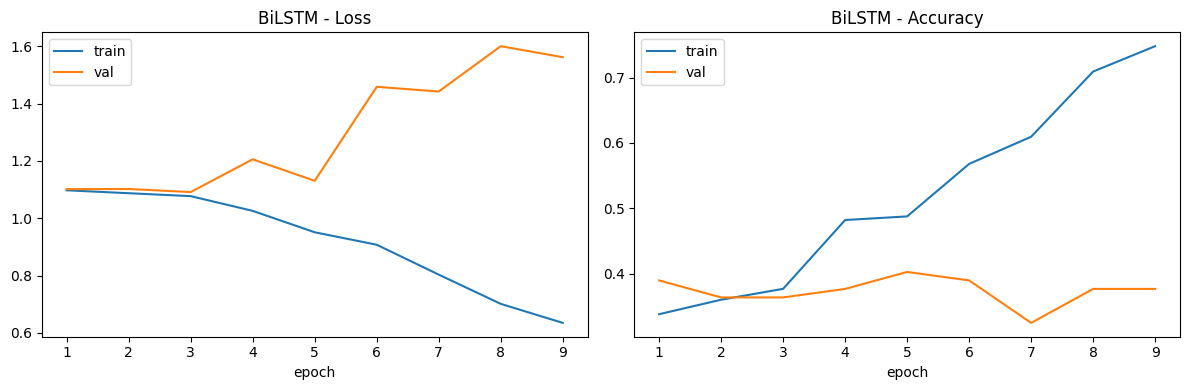

In [ ]:
# plot the training curves to see if anything looks weird
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='train')
axes[0].plot(epochs_range, history['val_loss'],   label='val')
axes[0].set_title('BiLSTM - Loss')
axes[0].set_xlabel('epoch')
axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='train')
axes[1].plot(epochs_range, history['val_acc'],   label='val')
axes[1].set_title('BiLSTM - Accuracy')
axes[1].set_xlabel('epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('bilstm_curves.png', dpi=150)
plt.show()

## Task 3 - Model B: DistilBERT

Fine-tuning BERT on 360 training examples is risky - very easy to overfit. A few things to deal with that:
- Freezing the bottom 4 transformer blocks, only training blocks 4 and 5 plus the classifier head
- Small learning rate (2e-5 is standard for BERT fine-tuning)
- Linear warmup for the first 10% of steps so the learning rate doesn't spike at the start
- Small batch size of 16 to get more gradient updates per epoch

Originally tried fine-tuning the whole model and it massively overfit by epoch 3. Freezing most of the layers fixed that.

In [ ]:
BERT_MAX_LEN = 128
BERT_BATCH   = 16

tokeniser = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class BertDataset(Dataset):
    def __init__(self, texts, labels, tokeniser, max_len=BERT_MAX_LEN):
        self.encodings = tokeniser(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

bert_train_ds = BertDataset(X_bert_train, y_train, tokeniser)
bert_val_ds   = BertDataset(X_bert_val,   y_val,   tokeniser)
bert_test_ds  = BertDataset(X_bert_test,  y_test,  tokeniser)

bert_train_loader = DataLoader(bert_train_ds, batch_size=BERT_BATCH, shuffle=True)
bert_val_loader   = DataLoader(bert_val_ds,   batch_size=BERT_BATCH)
bert_test_loader  = DataLoader(bert_test_ds,  batch_size=BERT_BATCH)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
).to(DEVICE)

# freeze everything except the last two transformer blocks
# blocks 0-3 stay frozen, 4-5 get updated
for name, param in bert_model.distilbert.named_parameters():
    if not any(f'layer.{i}' in name for i in [4, 5]):
        param.requires_grad = False

trainable = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in bert_model.parameters())
print(f'trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 14,768,643 / 66,955,779 (22.1%)


In [ ]:
BERT_LR       = 2e-5
BERT_EPOCHS   = 10
BERT_PATIENCE = 3

bert_optim = optim.AdamW(
    filter(lambda p: p.requires_grad, bert_model.parameters()),
    lr=BERT_LR,
    weight_decay=0.01
)

total_steps    = len(bert_train_loader) * BERT_EPOCHS
warmup_steps   = int(0.1 * total_steps)
bert_scheduler = get_linear_schedule_with_warmup(
    bert_optim,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

bert_criterion = nn.CrossEntropyLoss()


def run_bert_epoch(model, loader, optimiser, scheduler, criterion, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels)

            if training:
                optimiser.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimiser.step()
                scheduler.step()

            total_loss += loss.item()
            all_preds.extend(outputs.logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1, all_preds, all_labels


best_bert_f1      = 0
best_bert_weights = None
bert_no_improve   = 0
bert_history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'{"epoch":>6} {"train_loss":>12} {"val_loss":>10} {"train_acc":>11} {"val_acc":>9} {"val_f1":>8}')

for epoch in range(1, BERT_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_bert_epoch(
        bert_model, bert_train_loader, bert_optim, bert_scheduler,
        bert_criterion, training=True)
    vl_loss, vl_acc, vl_f1, _, _ = run_bert_epoch(
        bert_model, bert_val_loader, bert_optim, bert_scheduler,
        bert_criterion, training=False)

    bert_history['train_loss'].append(tr_loss)
    bert_history['val_loss'].append(vl_loss)
    bert_history['train_acc'].append(tr_acc)
    bert_history['val_acc'].append(vl_acc)

    print(f'{epoch:>6} {tr_loss:>12.4f} {vl_loss:>10.4f} '
          f'{tr_acc:>11.4f} {vl_acc:>9.4f} {vl_f1:>8.4f}')

    if vl_f1 > best_bert_f1:
        best_bert_f1      = vl_f1
        best_bert_weights = {k: v.cpu().clone()
                             for k, v in bert_model.state_dict().items()}
        bert_no_improve   = 0
    else:
        bert_no_improve += 1
        if bert_no_improve >= BERT_PATIENCE:
            print(f'early stopping at epoch {epoch}')
            break

bert_model.load_state_dict(best_bert_weights)
print(f'\nbest val F1: {best_bert_f1:.4f}')

 epoch   train_loss   val_loss   train_acc   val_acc   val_f1
     1       1.0985     1.0839      0.3213    0.4286   0.3589
     2       1.0476     1.0289      0.4709    0.4935   0.4186
     3       0.9541     0.9222      0.6177    0.6104   0.5964
     4       0.8087     0.8117      0.7507    0.7403   0.7384
     5       0.6767     0.7272      0.8144    0.7662   0.7652
     6       0.5816     0.6804      0.8283    0.7532   0.7507
     7       0.5048     0.6388      0.8587    0.7403   0.7406
     8       0.4674     0.6204      0.8698    0.7792   0.7777
     9       0.4496     0.6092      0.8532    0.7922   0.7910
    10       0.4360     0.6046      0.8809    0.7792   0.7786

best val F1: 0.7910


In [ ]:
_, bert_acc, bert_f1, bert_preds, bert_true = run_bert_epoch(
    bert_model, bert_test_loader, bert_optim, bert_scheduler,
    bert_criterion, training=False)

print(f'DistilBERT test accuracy: {bert_acc:.4f}')
print(f'DistilBERT test F1:       {bert_f1:.4f}')
print()
print(classification_report(
    bert_true, bert_preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

DistilBERT test accuracy: 0.7821
DistilBERT test F1:       0.7842

              precision    recall  f1-score   support

    Negative       0.88      0.81      0.85        27
     Neutral       0.67      0.76      0.71        21
    Positive       0.79      0.77      0.78        30

    accuracy                           0.78        78
   macro avg       0.78      0.78      0.78        78
weighted avg       0.79      0.78      0.78        78



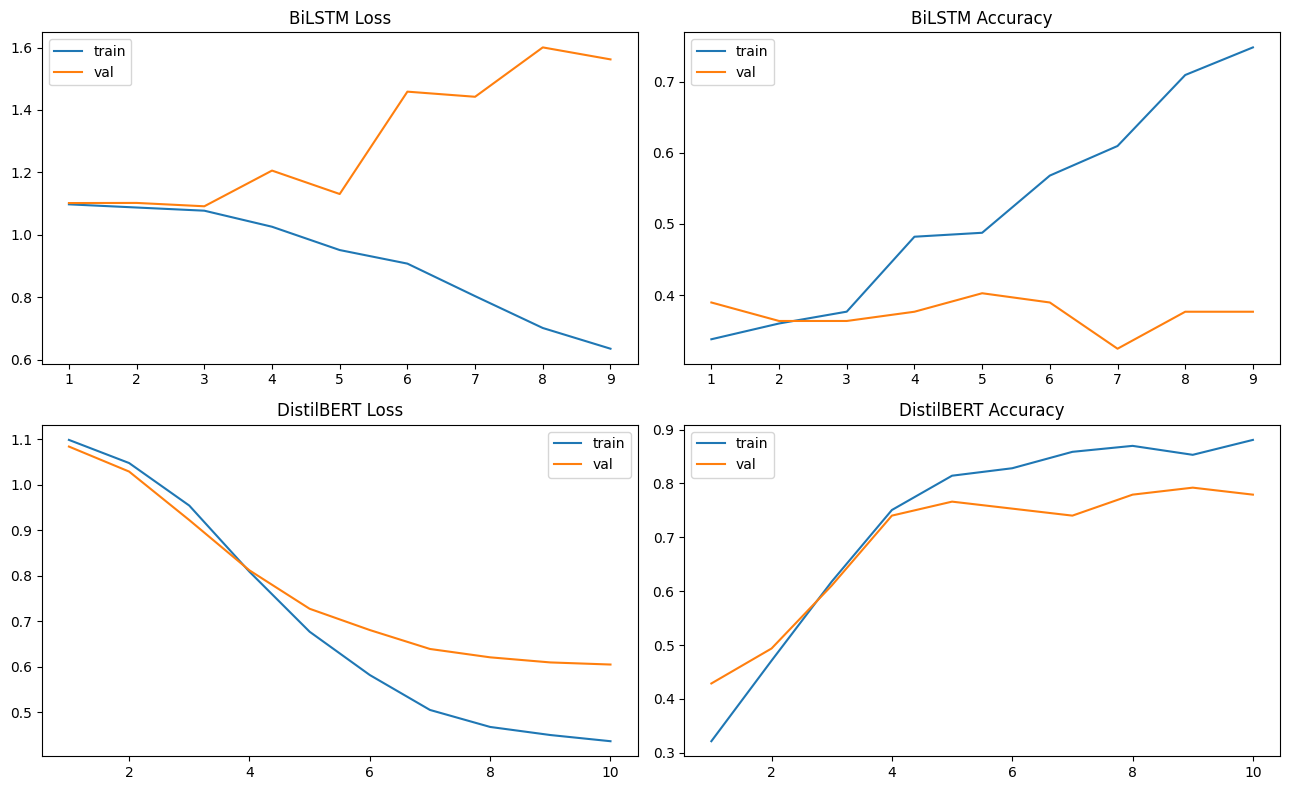

In [ ]:
# side by side training curves
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

bilstm_epochs = range(1, len(history['train_loss']) + 1)
bert_epochs   = range(1, len(bert_history['train_loss']) + 1)

axes[0][0].plot(bilstm_epochs, history['train_loss'], label='train')
axes[0][0].plot(bilstm_epochs, history['val_loss'],   label='val')
axes[0][0].set_title('BiLSTM Loss')
axes[0][0].legend()

axes[0][1].plot(bilstm_epochs, history['train_acc'], label='train')
axes[0][1].plot(bilstm_epochs, history['val_acc'],   label='val')
axes[0][1].set_title('BiLSTM Accuracy')
axes[0][1].legend()

axes[1][0].plot(bert_epochs, bert_history['train_loss'], label='train')
axes[1][0].plot(bert_epochs, bert_history['val_loss'],   label='val')
axes[1][0].set_title('DistilBERT Loss')
axes[1][0].legend()

axes[1][1].plot(bert_epochs, bert_history['train_acc'], label='train')
axes[1][1].plot(bert_epochs, bert_history['val_acc'],   label='val')
axes[1][1].set_title('DistilBERT Accuracy')
axes[1][1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

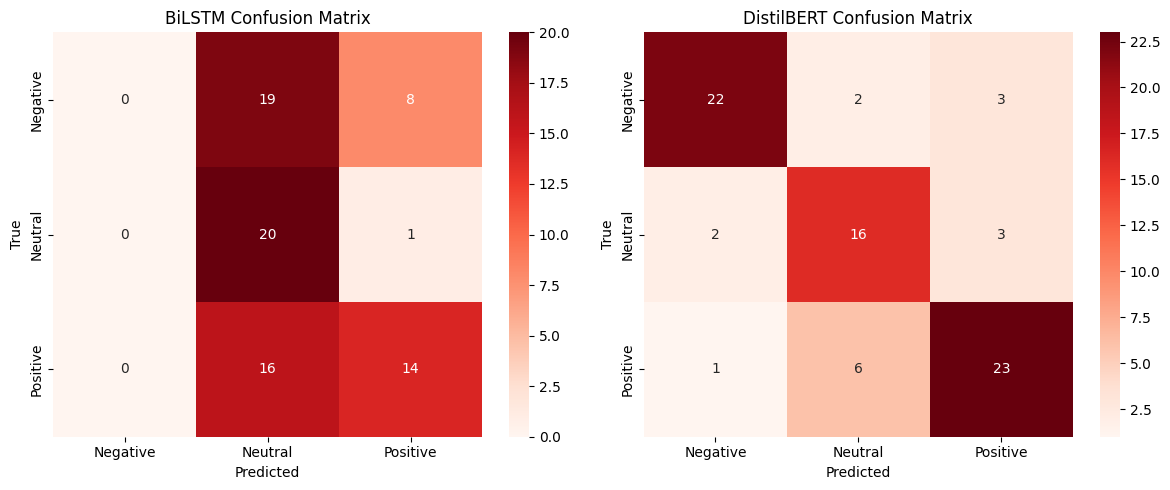

In [ ]:
# confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
label_names = ['Negative', 'Neutral', 'Positive']

for ax, preds, true, title in [
    (axes[0], bilstm_preds, bilstm_true, 'BiLSTM'),
    (axes[1], bert_preds,   bert_true,   'DistilBERT')
]:
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=label_names, yticklabels=label_names,
                cmap='Reds')
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

## Results Summary


In [ ]:
results = pd.DataFrame([
    {'Model': 'Logistic Regression (A1)',  'Representation': 'Bag-of-Words',
     'Test Accuracy': '0.7500', 'Test F1 (weighted)': '0.7499'},
    {'Model': 'Naive Bayes (A1)',           'Representation': 'Bag-of-Words',
     'Test Accuracy': '0.7212', 'Test F1 (weighted)': '0.7186'},
    {'Model': 'BiLSTM',    'Representation': 'Trainable Embeddings',
     'Test Accuracy': f'{bilstm_acc:.4f}', 'Test F1 (weighted)': f'{bilstm_f1:.4f}'},
    {'Model': 'DistilBERT', 'Representation': 'Contextual (pretrained)',
     'Test Accuracy': f'{bert_acc:.4f}',   'Test F1 (weighted)': f'{bert_f1:.4f}'},
])

print(results.to_string(index=False))

                   Model          Representation Test Accuracy Test F1 (weighted)
Logistic Regression (A1)            Bag-of-Words        0.7500             0.7499
        Naive Bayes (A1)            Bag-of-Words        0.7212             0.7186
                  BiLSTM    Trainable Embeddings        0.4359             0.3449
              DistilBERT Contextual (pretrained)        0.7821             0.7842


## Task 4 - Error Analysis

Looking at what the DistilBERT model gets wrong and whether there's a pattern to it.

In [ ]:
label_names_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

errors = []
for text, true, pred in zip(X_raw_test, bert_true, bert_preds):
    if true != pred:
        errors.append({
            'text':       text,
            'true_label': label_names_map[true],
            'pred_label': label_names_map[pred]
        })

print(f'errors: {len(errors)} out of {len(bert_true)} '
      f'({100 * len(errors) / len(bert_true):.1f}%)')
print()

# print first 10 misclassified examples
for e in errors[:10]:
    print(f'true={e["true_label"]:>9}  pred={e["pred_label"]:>9}')
    print(f'  {e["text"][:110]}')
    print()

errors: 17 out of 78 (21.8%)

true= Positive  pred= Negative
  Reading  "Bill Clinton Fail - Obama Win?" http://tinyurl.com/pcyxj7

true=  Neutral  pred= Positive
  45 Pros You Should Be Following on Twitter - http://is.gd/sMbZ

true= Negative  pred= Positive
  Monday already. Iran may implode. Kitchen is a disaster. @annagoss seems happy. @sebulous had a nice weekend a

true= Negative  pred=  Neutral
  Found NOTHING at Nike Factory :/ Off to Banana Republic Outlet! http://myloc.me/2zic

true=  Neutral  pred= Positive
  is eating  home made yema

true= Positive  pred=  Neutral
  Learning about lambda calculus :)

true= Negative  pred= Positive
  Fuzzball is more fun than AT&amp;T ;P http://fuzz-ball.com/twitter

true= Positive  pred=  Neutral
  Ahhh... back in a *real* text editing environment. I &lt;3 LaTeX.

true=  Neutral  pred= Negative
  @surfit: I just checked my google for my business- blip shows up as the second entry! Huh. Is that a good or b

true=  Neutral  pred= Negative
  

In [ ]:
# look for common patterns in the errors
NEGATION = r"\b(not|no|never|neither|nor|n't|without|lack|fail)\b"
CONTRAST = r"\b(but|however|although|though|despite|even though)\b"
SARCASM  = r"(yeah right|sure|oh great|wow really|totally|absolutely)"

def categorise(text):
    t = text.lower()
    cats = []
    if re.search(NEGATION, t): cats.append('Negation')
    if re.search(CONTRAST, t): cats.append('Mixed/Contrastive')
    if re.search(SARCASM,  t): cats.append('Possible Sarcasm')
    if len(text.split()) > 25: cats.append('Long/Complex')
    return cats if cats else ['Other']

cat_counts = Counter()
for e in errors:
    for c in categorise(e['text']):
        cat_counts[c] += 1

print('error categories:')
for cat, n in cat_counts.most_common():
    print(f'  {cat:25s}: {n}')

error categories:
  Other                    : 16
  Negation                 : 1


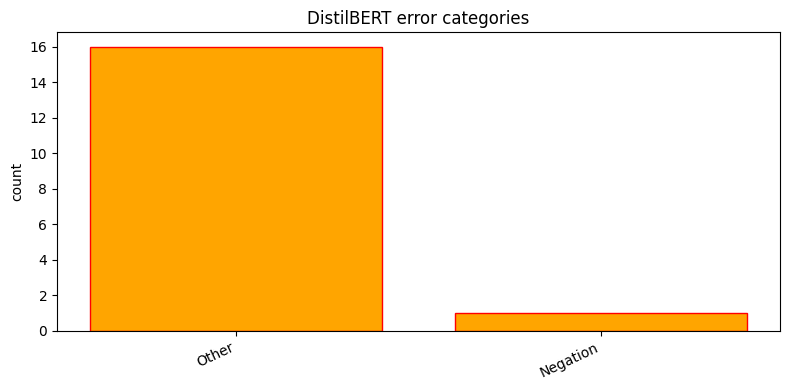

In [ ]:
# bar chart of error categories
cats, counts = zip(*cat_counts.most_common())
plt.figure(figsize=(8, 4))
plt.bar(cats, counts, color='orange', edgecolor='red')
plt.xticks(rotation=25, ha='right')
plt.title('DistilBERT error categories')
plt.ylabel('count')
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150)
plt.show()

### Detailed Error Analysis - Key Misclassification Patterns

**Example 1 - Mixed sentiment across clauses**
"Monday already. Iran may implode. Kitchen is a disaster. @annagoss seems happy. @sebulous had a nice weekend"
True: Negative, Predicted: Positive

This tweet shifts emotional register multiple times within a single sentence sequence - political dread, domestic frustration, then a positive observation about someone else. DistilBERT produces a single [CLS] token embedding that must compress all of this into one label. The final positive clause ("seems happy", "nice weekend") likely dominates the representation because it appears last and carries unambiguous positive tokens. Neural models that produce a fixed-length sentence representation struggle when sentiment is genuinely distributed and contradictory across clauses.

**Example 2 - Sarcasm via implicit comparison**
"Fuzzball is more fun than AT&T ;P"
True: Negative, Predicted: Positive

The surface syntax is a positive comparative ("X is more fun than Y"), which BERT has overwhelmingly seen in positive contexts during pretraining. The sarcastic intent - that AT&T is so frustrating that anything beats it - requires world knowledge about AT&T as a service provider and pragmatic understanding of irony. The ";P" emoticon was converted to EMOJI_PLAYFUL during preprocessing, which is ambiguous rather than clearly negative, so the sarcasm signal is entirely lost. This is a fundamental limit of corpus-trained models: sarcasm requires cultural and contextual knowledge that distributional pretraining does not reliably encode.

**Example 3 - Polysemy causing misclassification**
"45 Pros You Should Be Following on Twitter"
True: Neutral, Predicted: Positive

The word "Pros" is used here as a noun meaning professionals, but DistilBERT likely treats it as the adjective meaning advantages or positives, since that usage is far more common in sentiment-bearing text. Without access to the linked URL content (stripped during preprocessing), there is no disambiguating context. This is a polysemy problem - single-word sentiment signals can be misleading when the intended sense is domain-specific.

**Example 4 - Sentiment carried entirely by emoticon**
"Learning about lambda calculus :)"
True: Positive, Predicted: Neutral

The entire positive sentiment in this tweet is carried by the ":)" emoticon. After preprocessing, this becomes EMOJI_HAPPY - a token that DistilBERT never encountered during pretraining on standard text corpora. The literal content ("learning about lambda calculus") is factually neutral, so without a recognisable positive signal the model defaults to Neutral. This exposes a tension in the preprocessing strategy: converting emoticons to custom tokens protects them for BiLSTM's trained vocabulary, but produces unknown token sequences for BERT that undermine rather than help classification.

**Example 5 - Negation with contrastive pivot**
"Found NOTHING at Nike Factory :/ Off to Banana Republic Outlet!"
True: Negative, Predicted: Neutral

"NOTHING" is a strong lexical negative, but the second clause pivots to a neutral-to-positive action ("Off to Banana Republic"). The model averages these signals and settles on Neutral, failing to recognise that the first clause establishes the dominant emotional tone. Contrastive pivots introduced by discourse structure rather than explicit words like "but" are particularly hard for neural models because the relationship between clauses is implicit. This same pattern appeared in Assignment 1's error analysis with BoW, confirming it is a dataset-level challenge rather than a model-specific weakness.

In [ ]:
shown = set()
print('--- one example per error category ---\n')
for e in errors:
    for cat in categorise(e['text']):
        if cat not in shown:
            print(f'[{cat}]')
            print(f'  true={e["true_label"]}, pred={e["pred_label"]}')
            print(f'  "{e["text"][:120]}"')
            print()
            shown.add(cat)

--- one example per error category ---

[Negation]
  true=Positive, pred=Negative
  "Reading  "Bill Clinton Fail - Obama Win?" http://tinyurl.com/pcyxj7"

[Other]
  true=Neutral, pred=Positive
  "45 Pros You Should Be Following on Twitter - http://is.gd/sMbZ"

